<a href="https://colab.research.google.com/github/replysantosh-lang/ECARComputerVissionGenAI/blob/main/AI_08_QuestionNo8_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Magic Command
# Print multiple statements in same line
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
print("Magic Command Executed")

Magic Command Executed


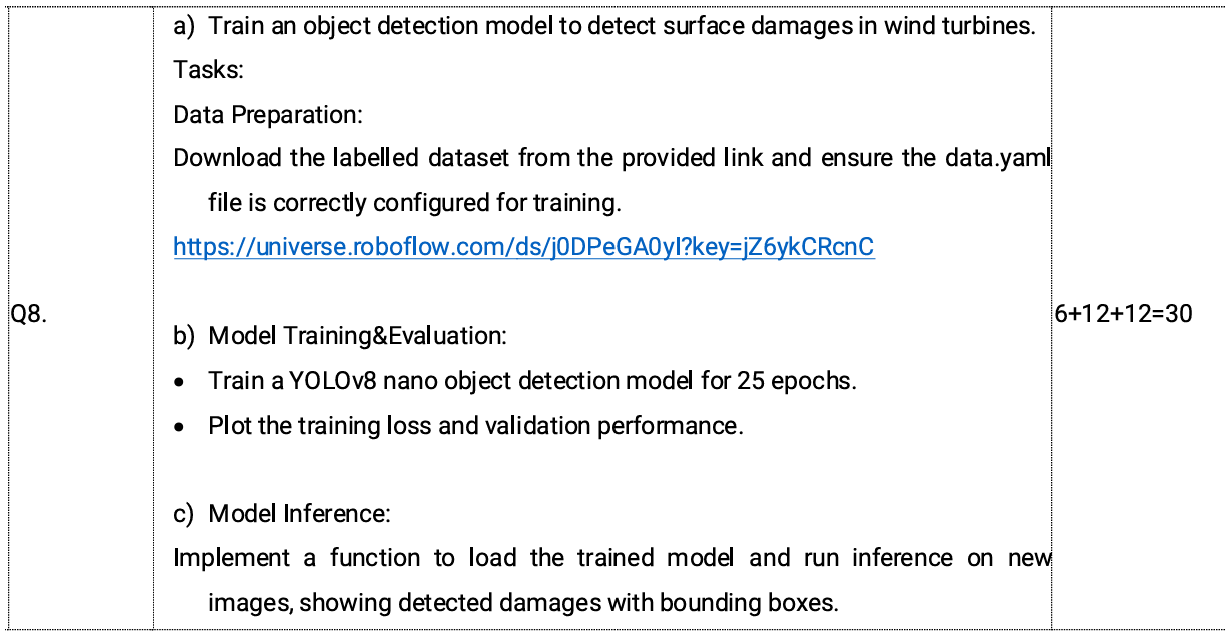

**Objective**

Build an Object Detection System that can detect surface damages in wind turbines using YOLOv8 Nano.

The solution consists of:

1. Data Preparation

2. Model Training

3. Model Evaluation

4. Visualization of Training Results

5. Inference on New Images

# **a) Data Preparation**

# Step 1: Install Required Libraries

In [10]:
# Install YOLOv8
# !pip install ultralytics

# Optional libraries
#!pip install matplotlib opencv-python

**Explanation : YOLOv8 is provided by the Ultralytics package. We also install OpenCV and Matplotlib for image processing and visualization.**

# Step 2: Download Dataset

The dataset is provided through Roboflow:

Dataset Link:

https://universe.roboflow.com/ds/j0DPeGA0yI?key=jZ6ykCRcnC

Download it in YOLO format.

After extraction your folder structure should look like:

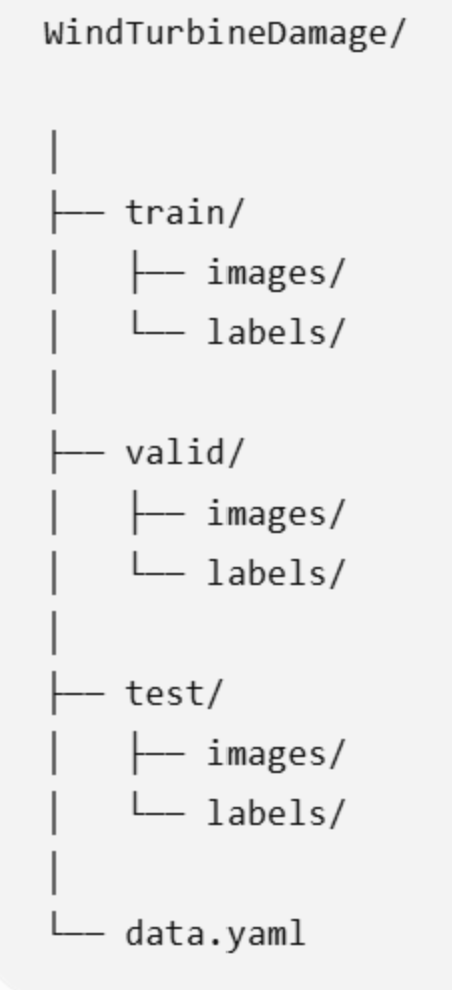

**Explanation : The dataset contains images and corresponding annotation files. YOLO requires images and labels to be organized in separate folders.**

In [11]:
!unzip WindTurbineDamage.zip

Archive:  WindTurbineDamage.zip
replace WindTurbineDamage/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: WindTurbineDamage/data.yaml  
  inflating: WindTurbineDamage/README.dataset.txt  
  inflating: WindTurbineDamage/README.roboflow.txt  
  inflating: WindTurbineDamage/test/images/DJI_0010_03_05_png.rf.3c27c0c4c47071574c6a27d83d992dba.jpg  
  inflating: WindTurbineDamage/test/images/DJI_0028_08_05_png.rf.8d36d1e5c43e30864cb8b965554e3653.jpg  
  inflating: WindTurbineDamage/test/images/DJI_0029_08_04_png.rf.54ed6796d38edbaa3d7c02471c542bf8.jpg  
  inflating: WindTurbineDamage/test/images/DJI_0030_01_04_png.rf.cbee817fc221c720a1580960b8a40d1f.jpg  
  inflating: WindTurbineDamage/test/images/DJI_0031_01_04_png.rf.c7706539e01e1f1566abe2b218dde6db.jpg  
  inflating: WindTurbineDamage/test/images/DJI_0038_04_06_png.rf.1147aa5ed93125a208530c3aa54b7df5.jpg  
  inflating: WindTurbineDamage/test/images/DJI_0041_05_06_png.rf.9772e361714f92c0f25925be2a4de5e3.jpg  
  inflating: Wi

# Step 3: Verify data.yaml

**Open data.yaml**

In [12]:
with open("WindTurbineDamage/data.yaml","r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['crack', 'damage', 'erosion']

roboflow:
  workspace: eepis-o8fee
  project: surface-damage-wind-turbine-qmqri
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/eepis-o8fee/surface-damage-wind-turbine-qmqri/dataset/2


**Expected structure:**

train: ../train/images

val: ../valid/images

test: ../test/images

nc: 1

names:
  0: damage

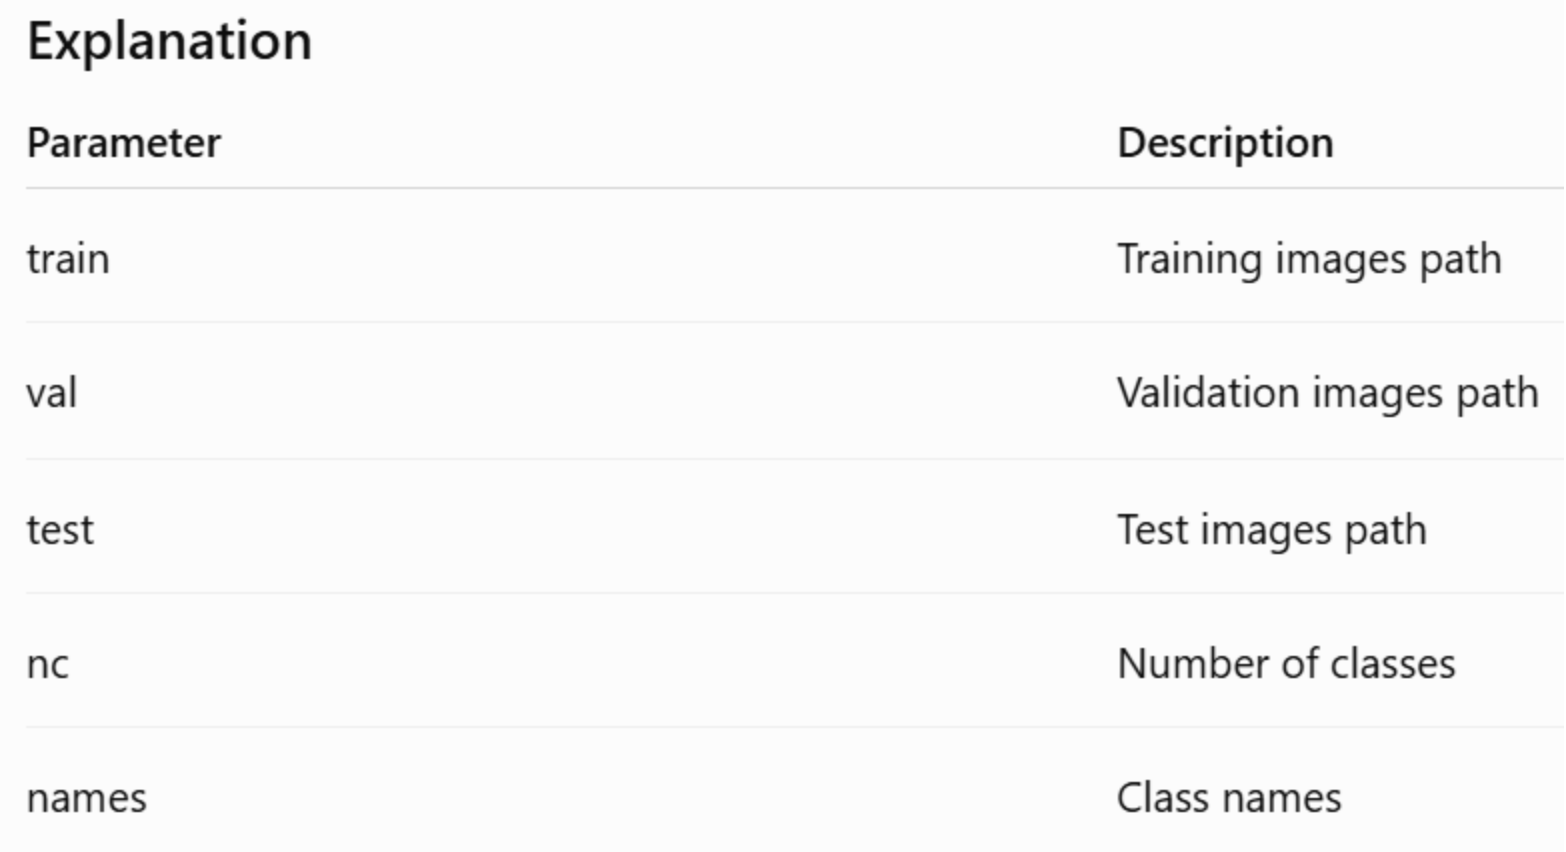

**This file tells YOLO where the dataset is located and what classes need to be detected.**

# **b) Model Training & Evaluation**

# Step 4: Load YOLOv8 Nano Model

**Explanation**

***YOLOv8 provides multiple pretrained models:***

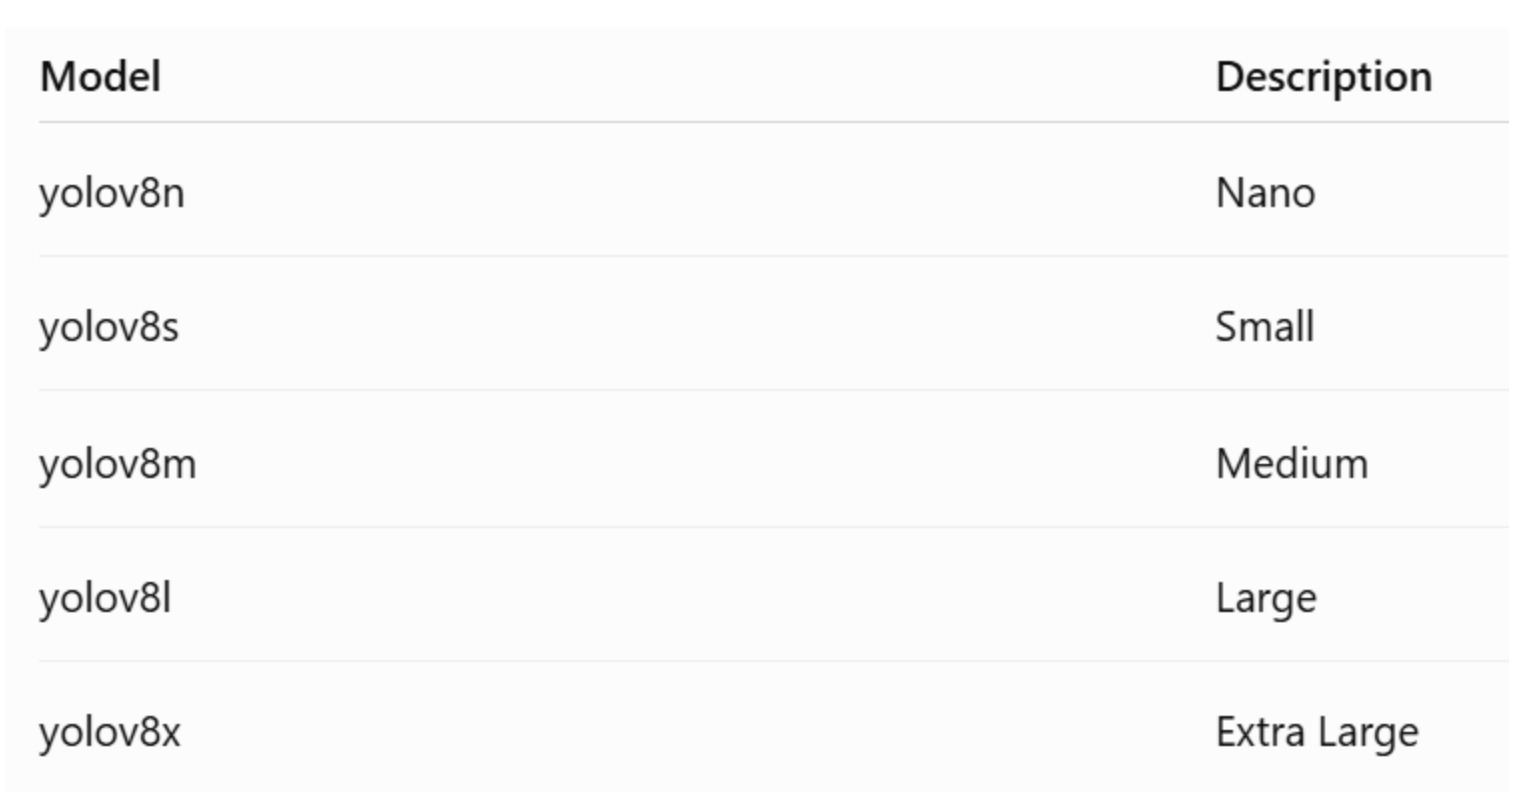

***For this assignment we use YOLOv8 Nano because it is lightweight and fast.***

In [13]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

# Step 5: Train YOLOv8 Nano for 25 Epochs

In [14]:
results = model.train(
    data="WindTurbineDamage/data.yaml",
    epochs=25,
    imgsz=640,
    batch=16,
    project="WindTurbine_Project",
    name="Damage_Detection"
)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=WindTurbineDamage/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Damage_Detection-2, nbs=64, nms=False, opset=None, optimize=False, optimize


**Explanation** **Parameters**

***1. epochs=25 : Train the model for 25 epochs.***

***2. imgsz=640 : Resize all images to 640 × 640.***

***3. batch=16 : Process 16 images simultaneously during training.***

Process 16 images at once.

**Expected Output:**

Epoch 1/25

loss=...

mAP=...

**The model learns to identify damaged regions on wind turbines.**

# Step 6: Validate the Model

**After training evaluate performance.**

In [24]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1595.9±641.7 MB/s, size: 37.1 KB)
val: Scanning /content/WindTurbineDamage/valid/labels.cache... 167 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 167/167 58.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 3.6it/s 3.1s
                   all        167        297      0.658      0.697       0.69       0.33
                 crack         78        108      0.612      0.519      0.523      0.205
                damage         49         84      0.718      0.762      0.775      0.392
               erosion         49        105      0.644       0.81      0.773      0.393
Speed: 4.2ms preprocess, 4.3ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val-3
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: arra

**Explanation**

**Important evaluation metrics:**

1. Metric	: Precision : 0.6579

Meaning : Correct detections among predicted detections

2. Metric	: Recall : 0.69

Meaning :	Ability to detect all damages

3.Metric : mAP50 : 0.690

Meaning : Detection accuracy at IoU=50%

4. Metric	: mAP50-95 : 0.3304

5. fitness': 0.3304

Meaning :Overall detection performance

**Higher values indicate better model performance.**


# Step 7: Locate Training Results

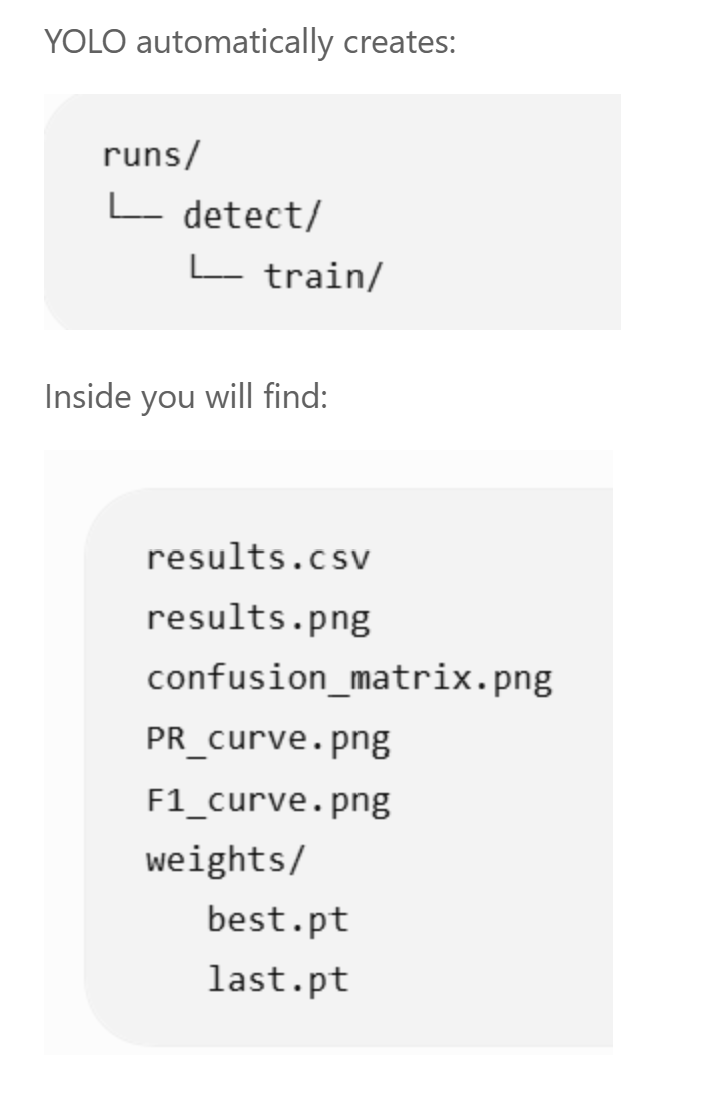

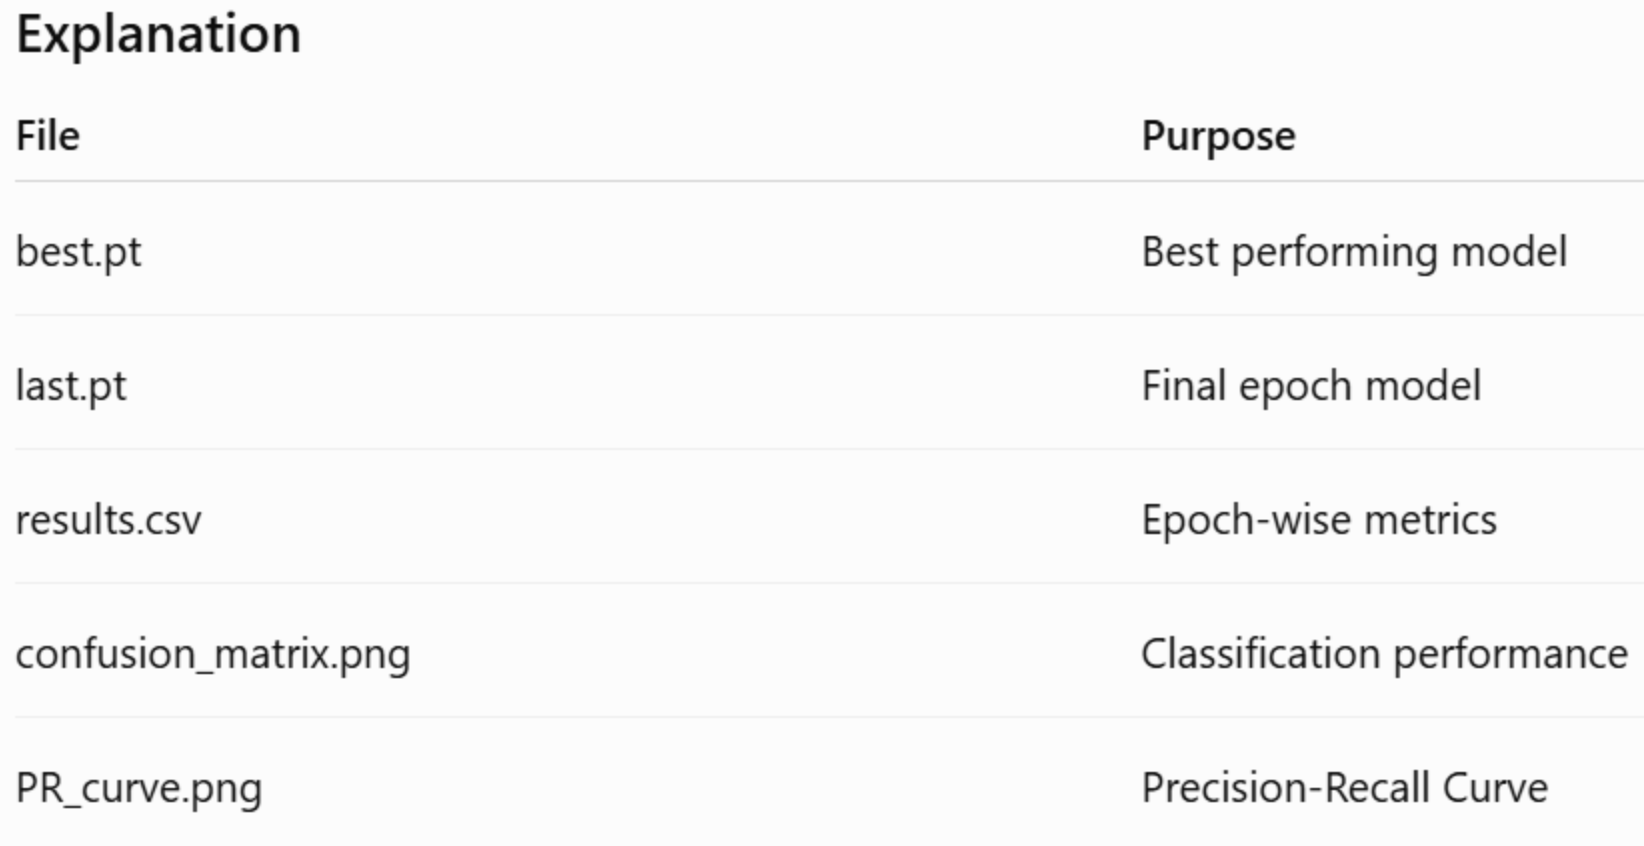

# Step 8: Plot Training Loss

***Read results.csv***

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

"""results = pd.read_csv(
   "runs/detect/train/results.csv"
)"""

results = pd.read_csv( "/content/runs/detect/WindTurbine_Project/Damage_Detection-2/results.csv")

print(results.head())

'results = pd.read_csv(\n   "runs/detect/train/results.csv"\n)'

   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   27.3138         2.01880         3.57522         1.64655   
1      2   52.9598         1.99757         2.80517         1.66384   
2      3   78.4115         2.02602         2.59482         1.71482   
3      4  103.6240         2.03891         2.45628         1.69213   
4      5  129.3110         2.00616         2.26507         1.67399   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.53742            0.17778           0.13555   
1               0.30922            0.35291           0.26133   
2               0.39631            0.39418           0.33521   
3               0.40787            0.24206           0.23108   
4               0.45385            0.36270           0.36308   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.06340       1.96921       3.88963       1.62856  0.000471   
1              0.09116       2.17497  

**Plot Training Loss**

<Figure size 1000x500 with 0 Axes>

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Loss')

Text(0.5, 1.0, 'Training Loss')

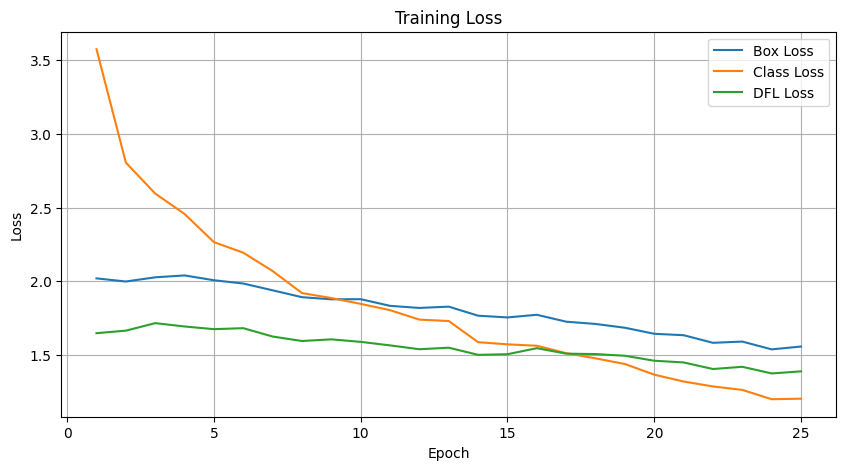

In [28]:
plt.figure(figsize=(10,5))

plt.plot(
    results['epoch'],
    results['train/box_loss'],
    label='Box Loss'
)

plt.plot(
    results['epoch'],
    results['train/cls_loss'],
    label='Class Loss'
)

plt.plot(
    results['epoch'],
    results['train/dfl_loss'],
    label='DFL Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid()

plt.show()

**Explanation**

This graph shows:

1. Bounding Box Loss

2. Classification Loss

3. Distribution Focal Loss

**A decreasing curve indicates successful learning.**

**Expected Output**

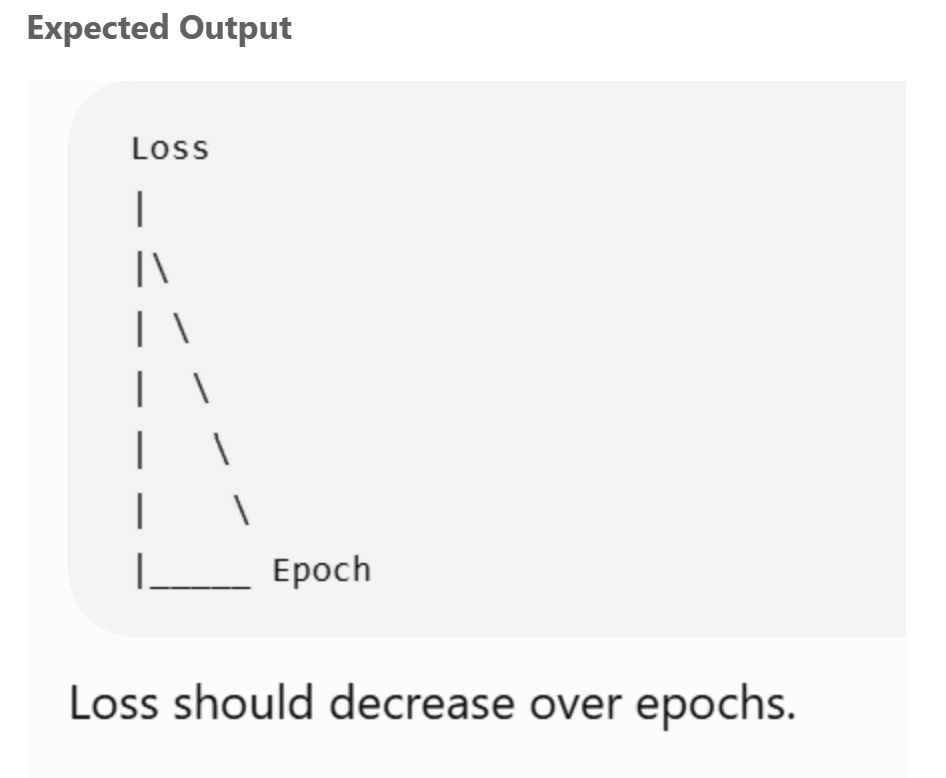

# Step 9: Plot Validation Performance

<Figure size 1000x500 with 0 Axes>

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Score')

Text(0.5, 1.0, 'Validation Performance')

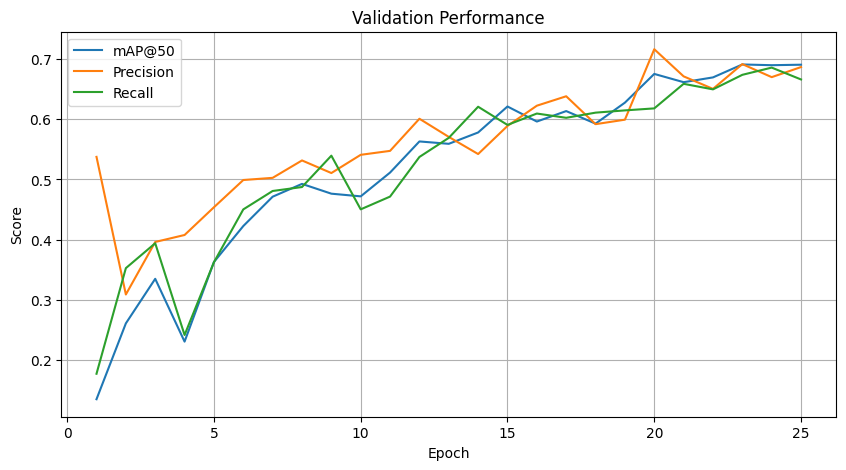

In [29]:
plt.figure(figsize=(10,5))

plt.plot(
    results['epoch'],
    results['metrics/mAP50(B)'],
    label='mAP@50'
)

plt.plot(
    results['epoch'],
    results['metrics/precision(B)'],
    label='Precision'
)

plt.plot(
    results['epoch'],
    results['metrics/recall(B)'],
    label='Recall'
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Performance")

plt.legend()
plt.grid()

plt.show()

**Explanation**

***This graph visualizes:***

Precision

Recall

mAP@50

**As training progresses these metrics should increase.**

# **c) Model Inference**

# Step 10: Load Best Trained Model

After training:

In [30]:
from ultralytics import YOLO

#best_model = YOLO(
#    "runs/detect/train/weights/best.pt"
#)

best_model = YOLO(
    "/content/runs/detect/WindTurbine_Project/Damage_Detection-2/weights/best.pt"
)


**Explanation : The best-performing model saved during training is loaded for inference.**

# Step 11: Run Inference on New Images

**Single Image Prediction**

In [31]:
results = best_model.predict(
    source="/content/WindTurbineDamage/test/images/DJI_0010_03_05_png.rf.3c27c0c4c47071574c6a27d83d992dba.jpg",
    conf=0.25,
    save=True
)


image 1/1 /content/WindTurbineDamage/test/images/DJI_0010_03_05_png.rf.3c27c0c4c47071574c6a27d83d992dba.jpg: 640x640 1 crack, 2 erosions, 9.0ms
Speed: 2.4ms preprocess, 9.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2


**Explanation**

*Parameters*

Parameter : source , Purpose : Input image

Parameter : conf , Purpose : Confidence threshold

Parameter : save , Purpose : Save preciction image

**Displaying the predicted image**

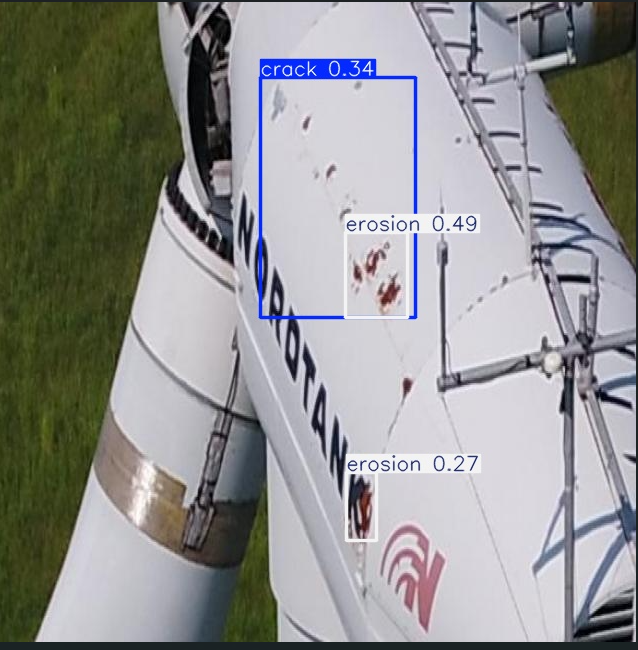

**YOLO will automatically draw:**

✔ Bounding Boxes

✔ Confidence Scores

✔ Class Labels

# Step 12: Custom Inference Function

In [41]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt


def detect_damage(
        model_path,
        image_path,
        conf_threshold=0.25):

    # Load model
    model = YOLO(model_path)

    # Prediction
    results = model.predict(
        image_path,
        conf=conf_threshold
    )

    # Annotated image
    annotated_img = results[0].plot()

    # Convert BGR → RGB
    annotated_img = cv2.cvtColor(
        annotated_img,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(10,8))
    plt.imshow(annotated_img)
    plt.axis("off")
    plt.title("Detected Wind Turbine Damage")
    plt.show()

    return results

***Explanation***

The function:

Loads the trained model.

Runs object detection.

Draws bounding boxes.

Displays detected damage regions.

# Step 13: Test Inference Function


image 1/1 /content/WindTurbineDamage/test/images/DJI_0010_03_05_png.rf.3c27c0c4c47071574c6a27d83d992dba.jpg: 640x640 1 crack, 2 erosions, 12.5ms
Speed: 3.6ms preprocess, 12.5ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


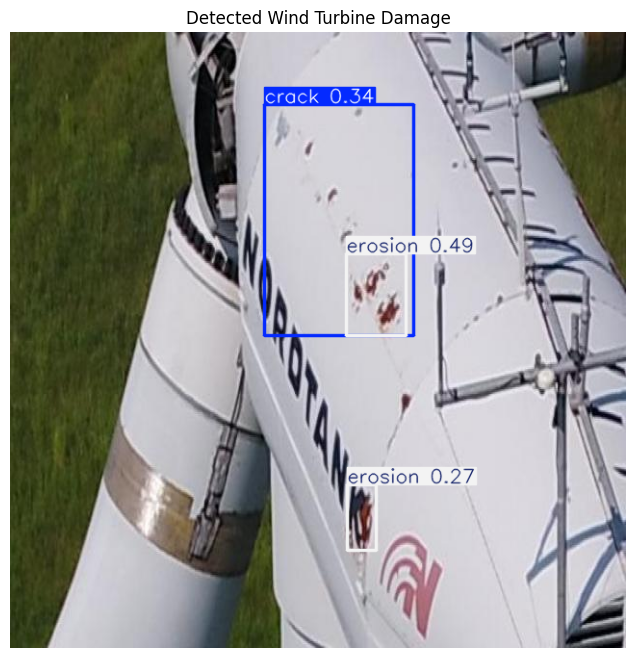

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'crack', 1: 'damage', 2: 'erosion'}
 obb: None
 orig_img: array([[[ 31,  69,  69],
         [ 27,  65,  65],
         [ 26,  65,  63],
         ...,
         [ 25,  34,  43],
         [ 13,  22,  31],
         [  0,   7,  16]],
 
        [[ 30,  68,  68],
         [ 26,  64,  64],
         [ 26,  65,  63],
         ...,
         [ 25,  34,  43],
         [ 12,  21,  30],
         [  0,   6,  15]],
 
        [[ 29,  67,  67],
         [ 27,  65,  65],
         [ 28,  67,  65],
         ...,
         [ 25,  34,  43],
         [ 12,  19,  28],
         [  0,   5,  14]],
 
        ...,
 
        [[ 21,  61,  49],
         [ 20,  60,  48],
         [ 20,  60,  48],
         ...,
         [159, 152, 155],
         [206, 199, 204],
         [204, 197, 202]],
 
        [[ 21,  61,  49],
         [ 20,  60,  48],
         [ 20,  60,  48],
      

In [44]:
detect_damage(
    model_path="/content/runs/detect/WindTurbine_Project/Damage_Detection-2/weights/best.pt",
    image_path="/content/WindTurbineDamage/test/images/DJI_0010_03_05_png.rf.3c27c0c4c47071574c6a27d83d992dba.jpg"
)

**Explanation : The function predicts damage locations on a new image and displays the result.**

# Step 14: Display Detection Details


image 1/1 /content/WindTurbineDamage/test/images/DJI_0225_04_02_png.rf.cd5489685a3cd516946f3b2889a0974b.jpg: 640x640 4 erosions, 7.2ms
Speed: 1.6ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


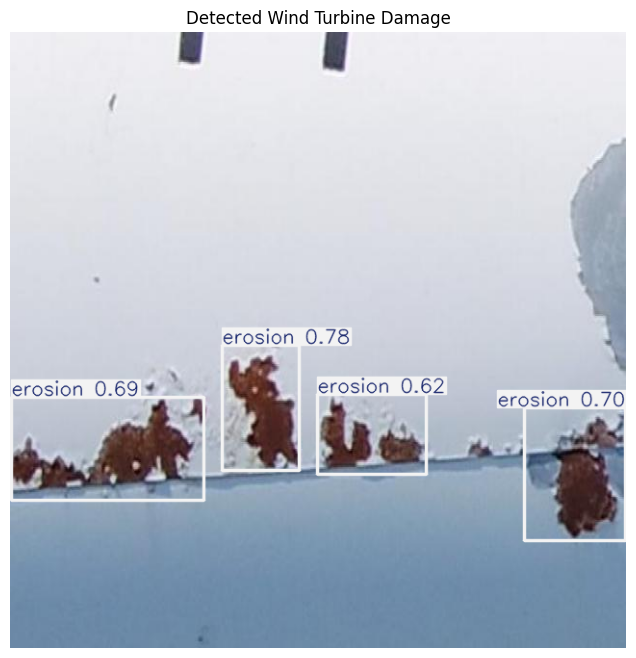

Bounding Box: 220.3712158203125 325.2254943847656 300.5516357421875 455.7776794433594
Confidence: 0.775
Class ID: 2
------------------
Bounding Box: 534.8072509765625 390.79620361328125 639.6282958984375 528.127685546875
Confidence: 0.701
Class ID: 2
------------------
Bounding Box: 1.73284912109375 379.36627197265625 201.996826171875 486.71600341796875
Confidence: 0.69
Class ID: 2
------------------
Bounding Box: 319.33038330078125 376.8480224609375 432.51934814453125 459.96502685546875
Confidence: 0.623
Class ID: 2
------------------


In [49]:
results = detect_damage(
    model_path="/content/runs/detect/WindTurbine_Project/Damage_Detection-2/weights/best.pt",
    image_path="/content/WindTurbineDamage/test/images/DJI_0225_04_02_png.rf.cd5489685a3cd516946f3b2889a0974b.jpg")

for box in results[0].boxes:

    x1, y1, x2, y2 = box.xyxy[0]

    confidence = float(box.conf[0])

    cls = int(box.cls[0])

    print("Bounding Box:",
          x1.item(),
          y1.item(),
          x2.item(),
          y2.item())

    print("Confidence:",
          round(confidence,3))

    print("Class ID:",
          cls)

    print("------------------")

**Explanation : This step prints:**

***1. Bounding box coordinates (x1,y1,x2,y2)***

***2. Confidence score***

***3. Detected class ID***

**Example Output:**

Bounding Box: 220 325 300 455

Confidence: 0.775

Class ID: 2 (erosion)

**Working Flow Diagram**

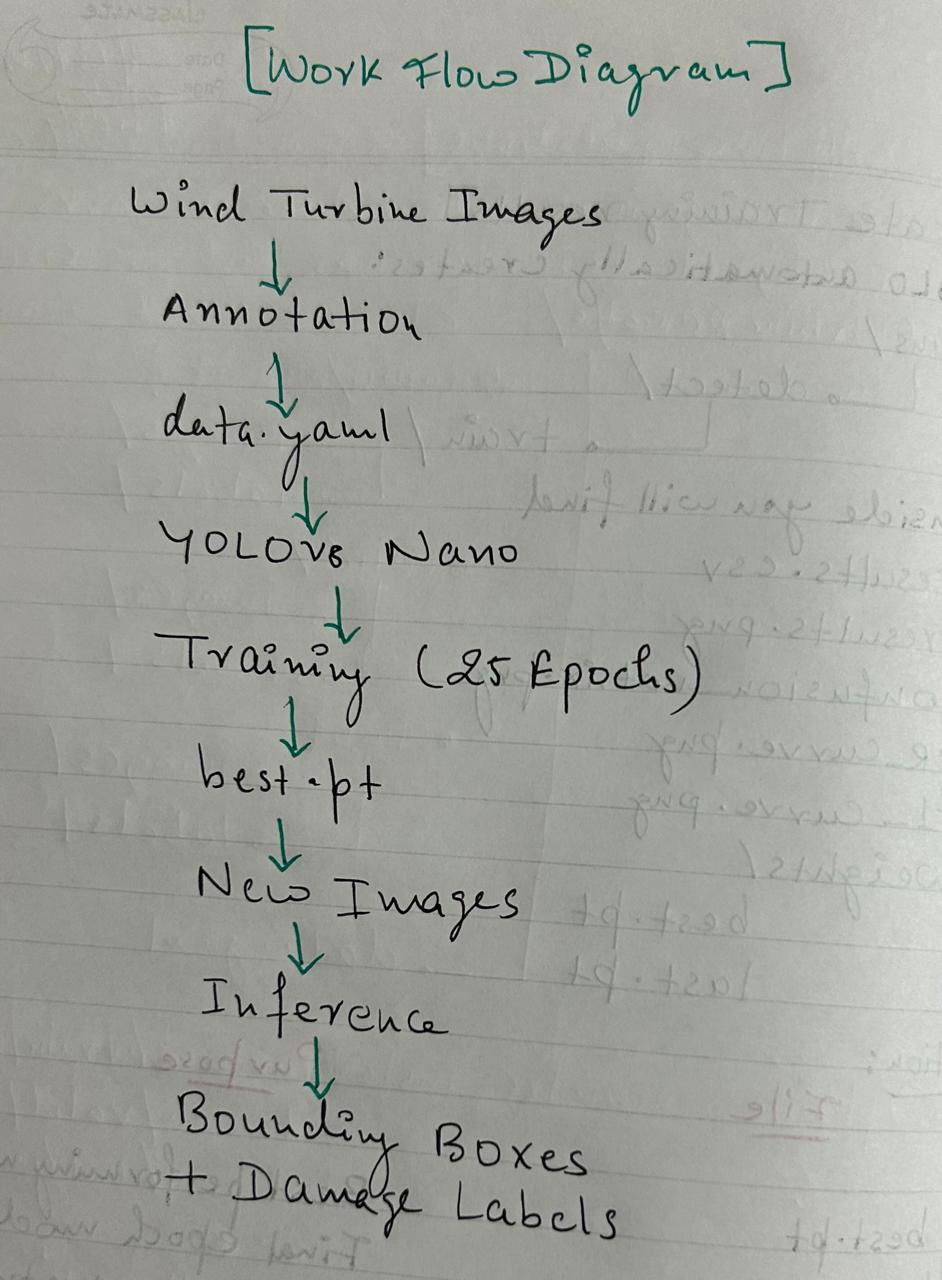

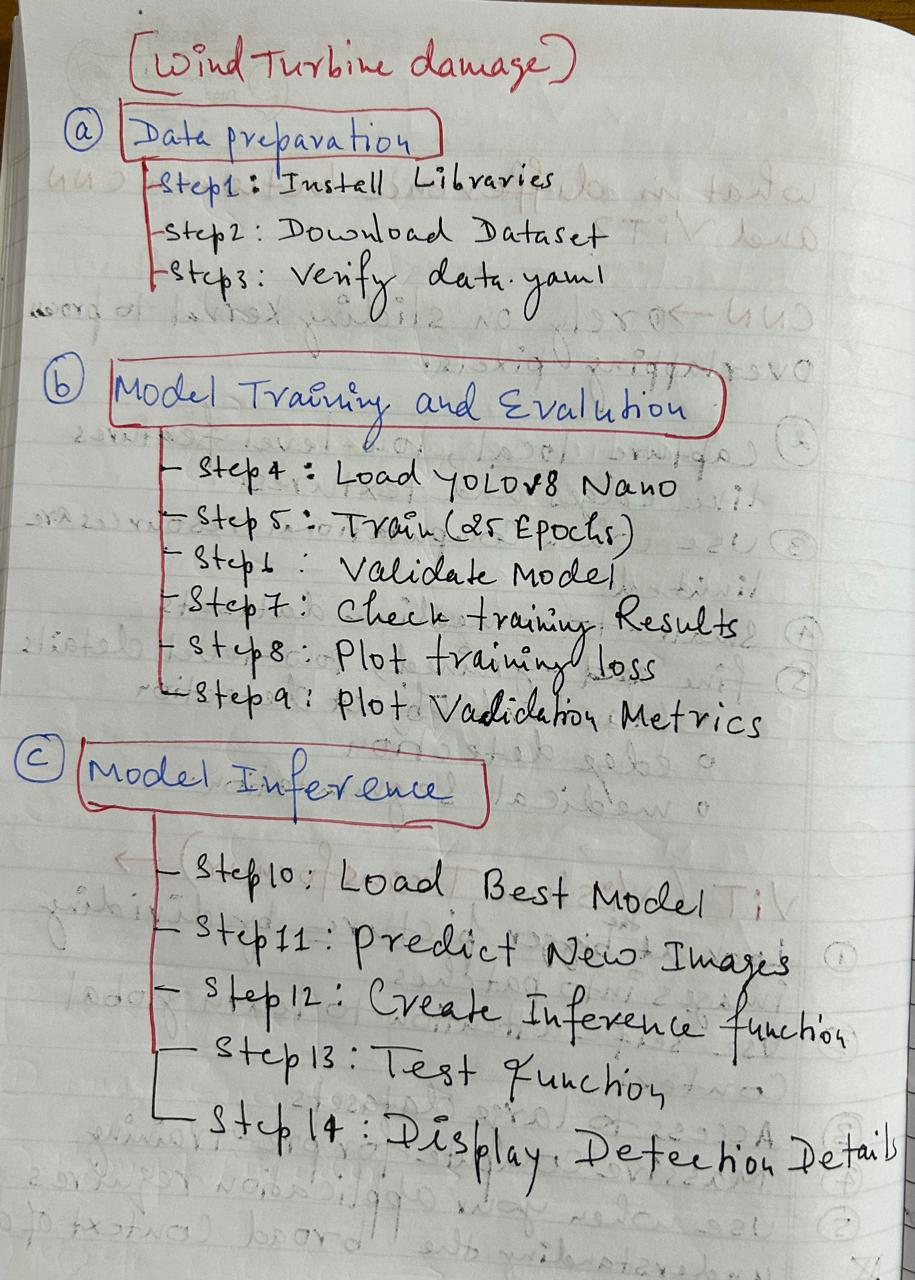

**Expected Outcome**

***a) Data Preparation***

Dataset downloaded from Roboflow.

data.yaml configured correctly.

Images and labels verified.

***b) Model Training & Evaluation***

YOLOv8 Nano trained for 25 epochs.

Loss curves decrease with training.

Precision, Recall and mAP metrics generated.

Validation graphs plotted.

**c) Model Inference**

Best model loaded successfully.

New images processed.

Surface damages detected with bounding boxes.

Confidence scores displayed for each detected damage.